In [1]:
%pip install -q pygam seaborn

In [2]:


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pygam import LogisticGAM, s, f
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20
DECISION_THRESHOLD = 0.50

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", context="notebook")

# CSV uploaded directly into the Google Colab session.
DATA_FILENAME = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
data_path = Path("/content") / DATA_FILENAME

if not data_path.exists():
    uploaded_csvs = list(Path("/content").glob("*.csv"))

    if len(uploaded_csvs) == 1:
        data_path = uploaded_csvs[0]
        print(f"Using uploaded CSV: {data_path.name}")
    else:
        raise FileNotFoundError(
            f"Could not find /content/{DATA_FILENAME}. "
            "Upload the CSV using the Files panel on the left."
        )

raw = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")

raw.head()

Loaded: /content/WA_Fn-UseC_-Telco-Customer-Churn.csv
Raw shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Validate and clean inputs

In [3]:
required_columns = {
    "customerID", "SeniorCitizen", "tenure", "InternetService", "Contract",
    "PaymentMethod", "MonthlyCharges", "TotalCharges", "Churn"
}
missing_required = required_columns.difference(raw.columns)
assert not missing_required, f"Missing required columns: {sorted(missing_required)}"

data = raw.copy()
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["ChurnFlag"] = data["Churn"].map({"No": 0, "Yes": 1})

quality_before = pd.Series({
    "rows": len(data),
    "unique_customer_ids": data["customerID"].nunique(),
    "duplicate_customer_ids": data["customerID"].duplicated().sum(),
    "missing_TotalCharges": data["TotalCharges"].isna().sum(),
    "missing_target": data["ChurnFlag"].isna().sum(),
})
display(quality_before.to_frame("count"))

# The standard IBM file has a small number of blank TotalCharges values for
# zero-tenure customers. Dropping them is transparent and affects <1% of rows.
data = data.dropna(subset=["TotalCharges", "ChurnFlag"]).copy()
data["ChurnFlag"] = data["ChurnFlag"].astype(int)

assert data["customerID"].is_unique, "Rows are not unique by customerID."
assert data["ChurnFlag"].isin([0, 1]).all(), "Target must be binary."
print(f"Clean shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
print(f"Rows removed: {len(raw) - len(data):,} ({(len(raw)-len(data))/len(raw):.2%})")

,count
rows,7043
unique_customer_ids,7043
duplicate_customer_ids,0
missing_TotalCharges,11
missing_target,0


Clean shape: 7,032 rows × 22 columns
Rows removed: 11 (0.16%)


### 2. EDA relevant to GAM assumptions

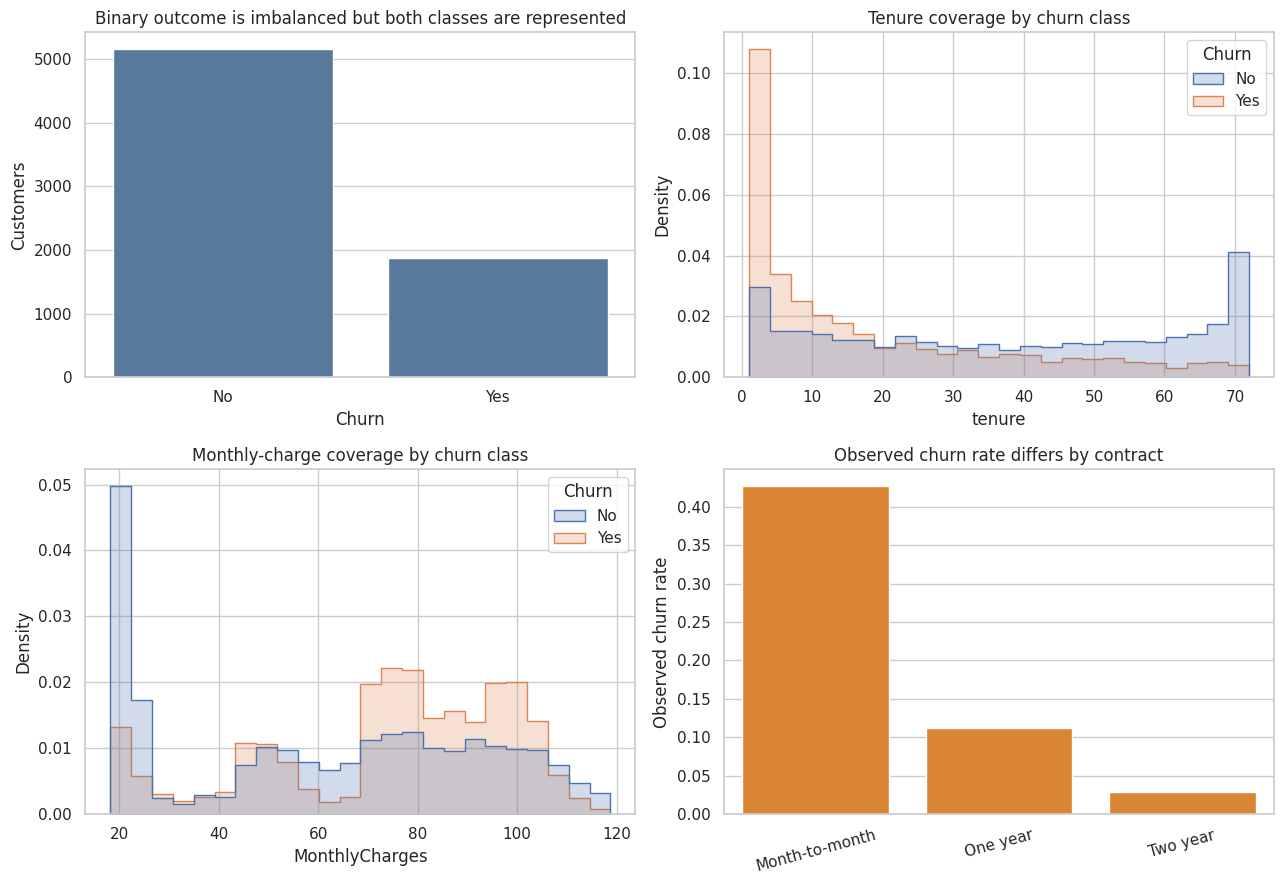

Class balance:


,customers,share
Churn,,
No,5163,0.734215
Yes,1869,0.265785


,churn_rate,customers
Contract,,
Month-to-month,0.427097,3875
One year,0.112772,1472
Two year,0.028487,1685


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(data=data, x="Churn", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Binary outcome is imbalanced but both classes are represented")
axes[0, 0].set_ylabel("Customers")

sns.histplot(data=data, x="tenure", hue="Churn", bins=24, element="step", stat="density",
             common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Tenure coverage by churn class")

sns.histplot(data=data, x="MonthlyCharges", hue="Churn", bins=24, element="step", stat="density",
             common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Monthly-charge coverage by churn class")

contract_rate = (data.groupby("Contract", observed=True)["ChurnFlag"]
                 .agg(churn_rate="mean", customers="size")
                 .sort_values("churn_rate", ascending=False))
sns.barplot(data=contract_rate.reset_index(), x="Contract", y="churn_rate", ax=axes[1, 1], color="#F58518")
axes[1, 1].set_title("Observed churn rate differs by contract")
axes[1, 1].set_ylabel("Observed churn rate")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("Class balance:")
display(data["Churn"].value_counts().to_frame("customers").assign(
    share=lambda table: table["customers"] / table["customers"].sum()
))
display(contract_rate)

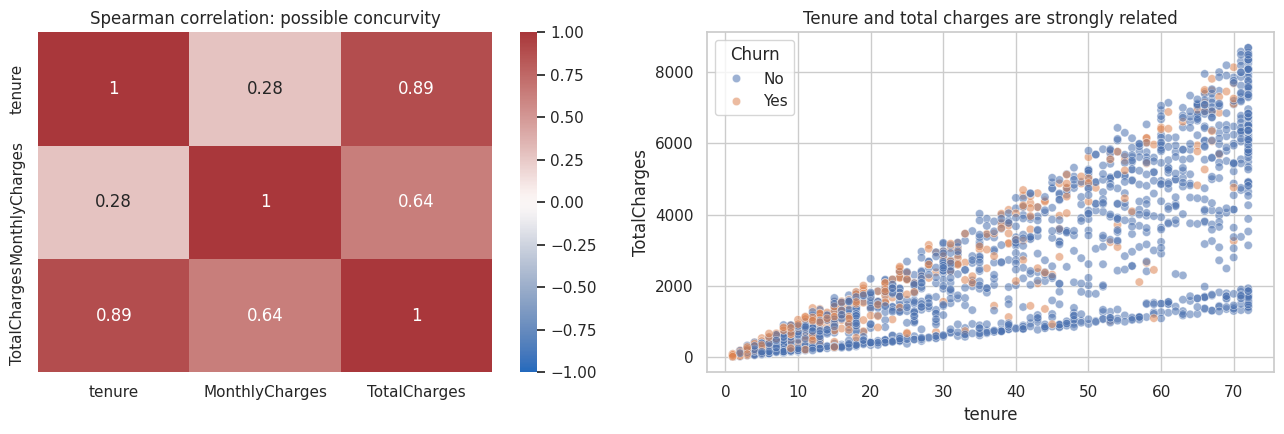

,feature,level,customers
0,SeniorCitizen,0,5890
1,SeniorCitizen,1,1142
2,Contract,Month-to-month,3875
3,Contract,One year,1472
4,Contract,Two year,1685
5,InternetService,DSL,2416
6,InternetService,Fiber optic,3096
7,InternetService,No,1520
8,PaymentMethod,Bank transfer (automatic),1542
9,PaymentMethod,Credit card (automatic),1521


Assumption evidence:
• One row per unique customer: True
• Positive-class share: 26.6%
• Strongest absolute continuous-predictor correlation: 0.889


In [5]:
continuous = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = data[continuous].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="vlag", ax=axes[0])
axes[0].set_title("Spearman correlation: possible concurvity")

sns.scatterplot(data=data.sample(min(2000, len(data)), random_state=RANDOM_STATE),
                x="tenure", y="TotalCharges", hue="Churn", alpha=0.55, ax=axes[1])
axes[1].set_title("Tenure and total charges are strongly related")
plt.tight_layout()
plt.show()

category_columns = ["SeniorCitizen", "Contract", "InternetService", "PaymentMethod"]
category_support = pd.concat(
    [data.groupby(column, observed=True).size().rename("customers").to_frame().assign(feature=column)
     for column in category_columns]
).reset_index(names="level")
display(category_support[["feature", "level", "customers"]])

print("Assumption evidence:")
print(f"• One row per unique customer: {data['customerID'].is_unique}")
print(f"• Positive-class share: {data['ChurnFlag'].mean():.1%}")
print(f"• Strongest absolute continuous-predictor correlation: "
      f"{corr.where(~np.eye(len(corr), dtype=bool)).abs().max().max():.3f}")

## Model

In [6]:
feature_names = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "SeniorCitizen", "Contract", "InternetService", "PaymentMethod"
]
continuous_features = feature_names[:3]
factor_features = feature_names[3:]

model_data = data[feature_names + ["ChurnFlag"]].copy()
category_maps = {}
for column in factor_features:
    categories = sorted(model_data[column].dropna().unique().tolist(), key=str)
    category_maps[column] = {value: index for index, value in enumerate(categories)}
    model_data[column] = model_data[column].map(category_maps[column]).astype(int)

print("Factor encodings (used only as category labels, not numeric distances):")
for feature, mapping in category_maps.items():
    print(f"{feature}: {mapping}")

X = model_data[feature_names].to_numpy(dtype=float)
y = model_data["ChurnFlag"].to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Training rows: {len(y_train):,}; test rows: {len(y_test):,}")
print(f"Training churn rate: {y_train.mean():.1%}; test churn rate: {y_test.mean():.1%}")

Factor encodings (used only as category labels, not numeric distances):
SeniorCitizen: {0: 0, 1: 1}
Contract: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
InternetService: {'DSL': 0, 'Fiber optic': 1, 'No': 2}
PaymentMethod: {'Bank transfer (automatic)': 0, 'Credit card (automatic)': 1, 'Electronic check': 2, 'Mailed check': 3}
Training rows: 5,625; test rows: 1,407
Training churn rate: 26.6%; test churn rate: 26.6%


In [7]:
# Smooth continuous terms + factor terms. A common smoothing penalty is tuned
# on training data only, leaving the test set untouched for final evaluation.
terms = s(0, n_splines=12) + s(1, n_splines=12) + s(2, n_splines=12)
for feature_index in range(3, len(feature_names)):
    terms += f(feature_index)

gam = LogisticGAM(terms, max_iter=500)
lambda_grid = np.logspace(-2, 2, 7)
gam.gridsearch(X_train, y_train, lam=lambda_grid, progress=False)

print("Selected smoothing penalties:", np.asarray(gam.lam).round(4).ravel())
print(f"Effective degrees of freedom: {gam.statistics_['edof']:.2f}")
print(f"Training pseudo-R² (explained deviance): "
      f"{gam.statistics_['pseudo_r2']['explained_deviance']:.3f}")

Selected smoothing penalties: [4.6416 4.6416 4.6416 4.6416 4.6416 4.6416 4.6416]
Effective degrees of freedom: 22.84
Training pseudo-R² (explained deviance): 0.288


## Results

,held-out test value
ROC-AUC,0.836
Accuracy,0.796
Precision,0.651
Recall,0.503
F1,0.567
Brier score (lower is better),0.140
Majority-class accuracy baseline,0.734


              precision    recall  f1-score   support

    No churn       0.83      0.90      0.87      1033
       Churn       0.65      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



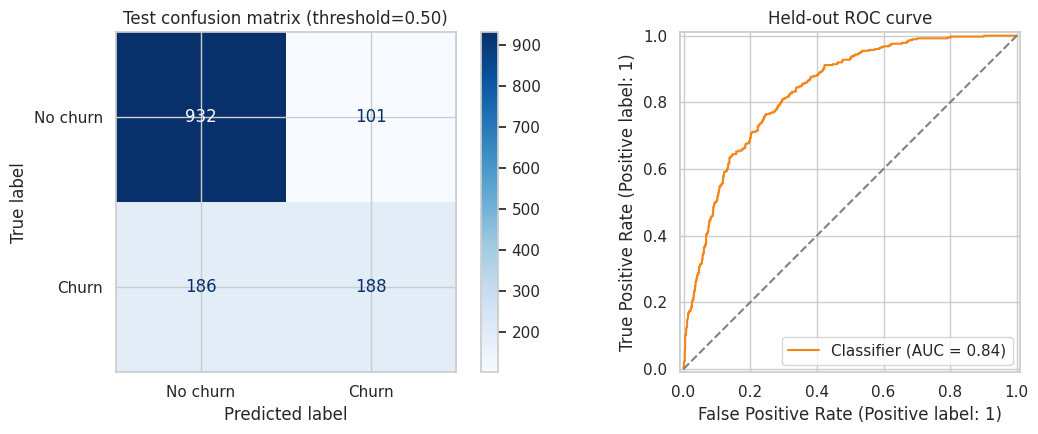

In [8]:
test_probability = gam.predict_mu(X_test)
test_prediction = (test_probability >= DECISION_THRESHOLD).astype(int)

metrics = pd.Series({
    "ROC-AUC": roc_auc_score(y_test, test_probability),
    "Accuracy": accuracy_score(y_test, test_prediction),
    "Precision": precision_score(y_test, test_prediction, zero_division=0),
    "Recall": recall_score(y_test, test_prediction, zero_division=0),
    "F1": f1_score(y_test, test_prediction, zero_division=0),
    "Brier score (lower is better)": brier_score_loss(y_test, test_probability),
    "Majority-class accuracy baseline": max(y_test.mean(), 1-y_test.mean()),
})
display(metrics.to_frame("held-out test value").style.format("{:.3f}"))
print(classification_report(y_test, test_prediction, target_names=["No churn", "Churn"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_prediction, display_labels=["No churn", "Churn"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Test confusion matrix (threshold={DECISION_THRESHOLD:.2f})")
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1], color="#F58518")
axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title("Held-out ROC curve")
plt.tight_layout()
plt.show()

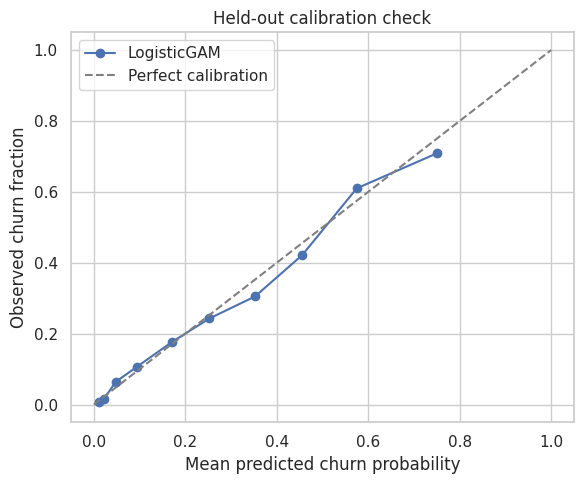

,mean_predicted_probability,observed_churn_fraction
0,0.011,0.007
1,0.021,0.014
2,0.048,0.064
3,0.094,0.106
4,0.172,0.177
5,0.253,0.243
6,0.352,0.305
7,0.455,0.421
8,0.575,0.610
9,0.751,0.709


In [9]:
observed_fraction, predicted_mean = calibration_curve(
    y_test, test_probability, n_bins=10, strategy="quantile"
)
plt.figure(figsize=(6, 5))
plt.plot(predicted_mean, observed_fraction, marker="o", label="LogisticGAM")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.xlabel("Mean predicted churn probability")
plt.ylabel("Observed churn fraction")
plt.title("Held-out calibration check")
plt.legend()
plt.tight_layout()
plt.show()

calibration_table = pd.DataFrame({
    "mean_predicted_probability": predicted_mean,
    "observed_churn_fraction": observed_fraction,
})
display(calibration_table.round(3))

### Smooth-effect plots

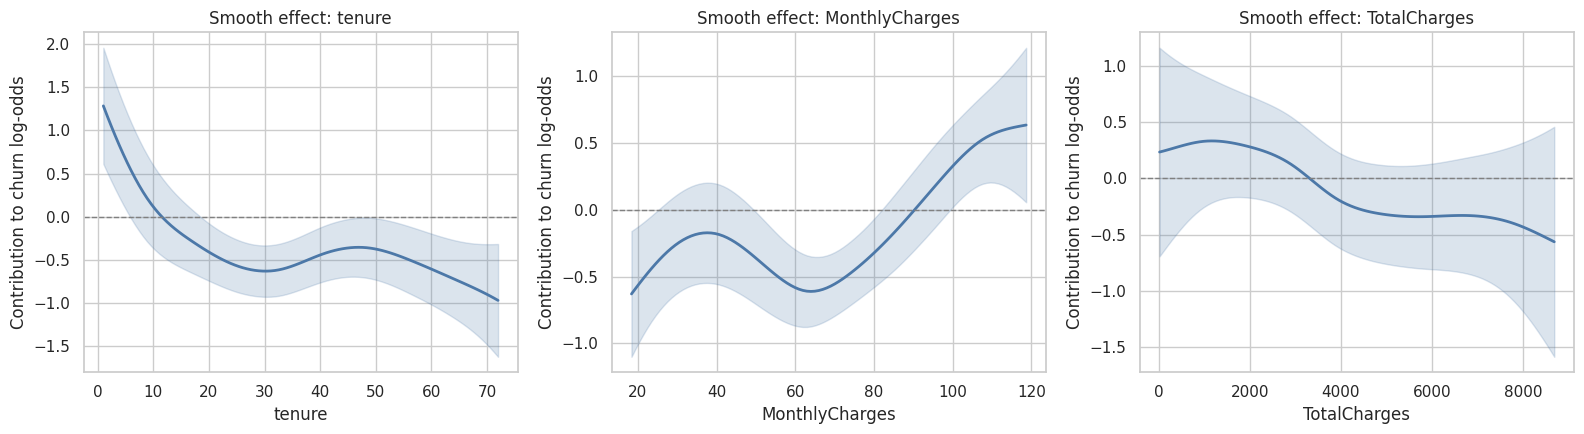

Curves are additive contributions on the log-odds scale; shaded bands are 95% confidence intervals.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for term_index, feature, axis in zip(range(3), continuous_features, axes):
    grid = gam.generate_X_grid(term=term_index)
    partial, interval = gam.partial_dependence(term=term_index, X=grid, width=0.95)
    axis.plot(grid[:, term_index], partial, color="#4C78A8", linewidth=2)
    axis.fill_between(grid[:, term_index], interval[:, 0], interval[:, 1], color="#4C78A8", alpha=0.2)
    axis.axhline(0, color="gray", linestyle="--", linewidth=1)
    axis.set_xlabel(feature)
    axis.set_ylabel("Contribution to churn log-odds")
    axis.set_title(f"Smooth effect: {feature}")
plt.tight_layout()
plt.show()

print("Curves are additive contributions on the log-odds scale; shaded bands are 95% confidence intervals.")

In [11]:
# A probability scale aid: vary one continuous feature at its 10th, 50th, and
# 90th percentiles while holding the others at a representative median/mode profile.
representative = np.zeros(len(feature_names), dtype=float)
representative[:3] = np.median(X_train[:, :3], axis=0)
for j in range(3, len(feature_names)):
    values, counts = np.unique(X_train[:, j].astype(int), return_counts=True)
    representative[j] = values[np.argmax(counts)]

profile_rows = []
for feature_index, feature in enumerate(continuous_features):
    for percentile, value in zip([10, 50, 90], np.percentile(X_train[:, feature_index], [10, 50, 90])):
        profile = representative.copy()
        profile[feature_index] = value
        probability = float(gam.predict_mu(profile.reshape(1, -1))[0])
        profile_rows.append({
            "feature": feature,
            "percentile": percentile,
            "feature_value": value,
            "predicted_churn_probability": probability,
        })

profile_effects = pd.DataFrame(profile_rows)
display(profile_effects.style.format({
    "feature_value": "{:.2f}",
    "predicted_churn_probability": "{:.1%}",
}))
print("These are representative-profile predictions, not causal treatment effects or population averages.")

,feature,percentile,feature_value,predicted_churn_probability
0,tenure,10,2.00,74.3%
1,tenure,50,29.00,33.5%
2,tenure,90,69.00,28.4%
3,MonthlyCharges,10,20.05,33.0%
4,MonthlyCharges,50,70.60,33.5%
5,MonthlyCharges,90,102.83,56.8%
6,TotalCharges,10,84.69,31.6%
7,TotalCharges,50,1410.25,33.5%
8,TotalCharges,90,6017.80,20.6%


These are representative-profile predictions, not causal treatment effects or population averages.


5. Final Interpretation & Limitations
Smooth Effect Interpretation:

Tenure: The GAM shows a strong non-linear decrease in churn risk as tenure increases, particularly in the first 20 months.
Monthly Charges: The relationship is more complex, suggesting higher churn risk at specific price tiers.


Limitations of GAM:

Complexity: Harder to summarize than simple coefficients in a linear model.
Computation: Grid searching for the best 'lambda' (smoothness) takes significantly more time than fitting a simple logistic regression.